In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder,MinMaxScaler

In [4]:
df = pd.read_csv("data kotor\FIFA PLAYER SKOR.csv")
df.head(5)

<>:1: SyntaxWarning: invalid escape sequence '\F'
<>:1: SyntaxWarning: invalid escape sequence '\F'
C:\Users\HP\AppData\Local\Temp\ipykernel_8160\1593183900.py:1: SyntaxWarning: invalid escape sequence '\F'
  df = pd.read_csv("data kotor\FIFA PLAYER SKOR.csv")


,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [5]:
df.shape

(19667, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [7]:
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df_num = df.select_dtypes(include=[np.number])
df_num.head(5)

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
0,30,68,68,0.65,1660
1,35,67,67,0.35,1620
2,28,63,65,0.20,1480
3,32,68,68,0.50,1695
4,30,66,66,0.40,1640


(19667, 9)

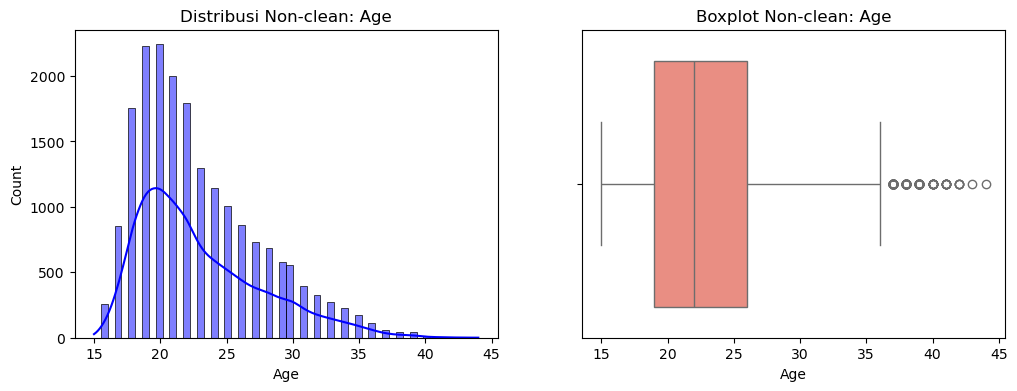

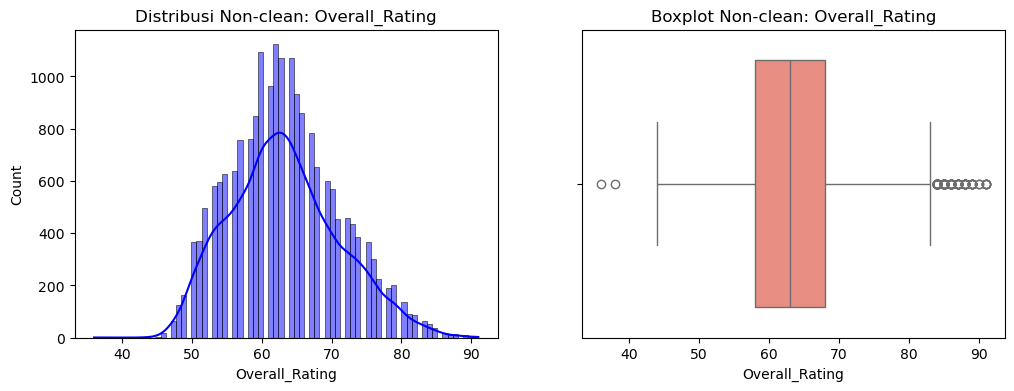

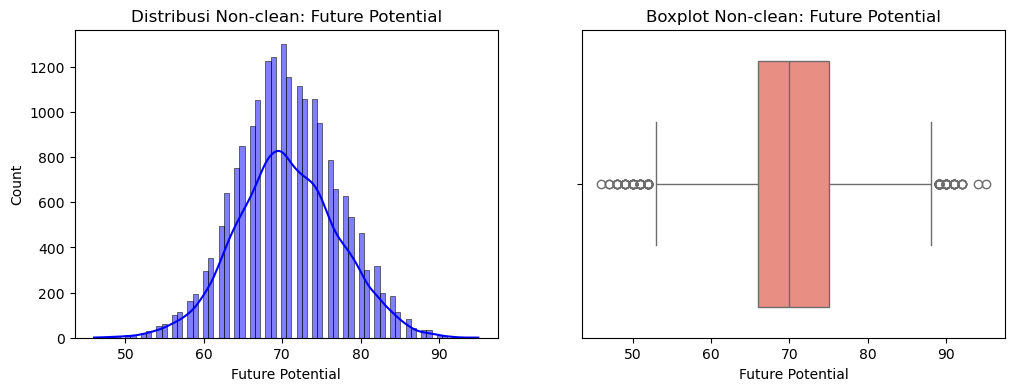

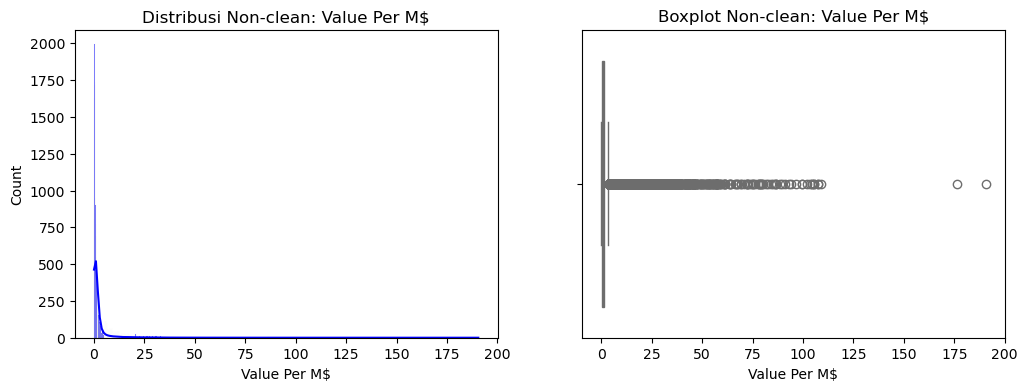

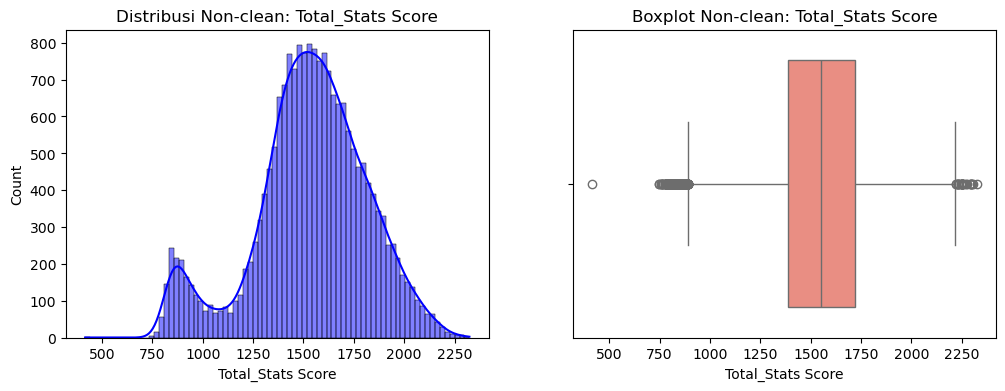

In [10]:
fitur_numerik = df_num.columns
for col in fitur_numerik:
    plt.figure(figsize=(12, 4))
    # Boxplot Sebelum
    plt.subplot(1, 2, 1) # 1 baris, 2 kolom, posisi ke-1
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Distribusi Non-clean: {col}')

    plt.subplot(1, 2, 2) # 1 baris, 2 kolom, posisi ke-2
    sns.boxplot(x=df[col], color='salmon')
    plt.title(f'Boxplot Non-clean: {col}')
df.shape

In [11]:
quartiles = df_num.quantile([0,0.25,0.50,0.75,1.0])
quartiles.index = ["minimum","Q1","median","Q3","maksimum"]
quartiles

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
minimum,15.0,36.0,46.0,0.000,416.0
Q1,19.0,58.0,66.0,0.325,1388.0
median,22.0,63.0,70.0,0.675,1549.0
Q3,26.0,68.0,75.0,1.600,1720.0
maksimum,44.0,91.0,95.0,190.500,2324.0


In [12]:
IQR = quartiles.loc["Q3"] - quartiles.loc["Q1"] #IQRnya berubah
lower_fence = quartiles.loc["Q1"] - (1.5 * IQR)
higher_fence = quartiles.loc["Q3"] + (1.5 * IQR)

print(f"IQR: {IQR} ")
print("\nbatas bawah: ",lower_fence)
print("\nbatas atas: ",higher_fence)

IQR: Age                    7.000
Overall_Rating        10.000
Future Potential       9.000
Value Per M$           1.275
Total_Stats Score    332.000
dtype: float64 

batas bawah:  Age                    8.5000
Overall_Rating        43.0000
Future Potential      52.5000
Value Per M$          -1.5875
Total_Stats Score    890.0000
dtype: float64

batas atas:  Age                    36.5000
Overall_Rating         83.0000
Future Potential       88.5000
Value Per M$            3.5125
Total_Stats Score    2218.0000
dtype: float64


In [13]:
outliers_index = df[((df_num < lower_fence) | (df_num > higher_fence)).any(axis=1)].index
df = df.drop(outliers_index)

(16313, 9)

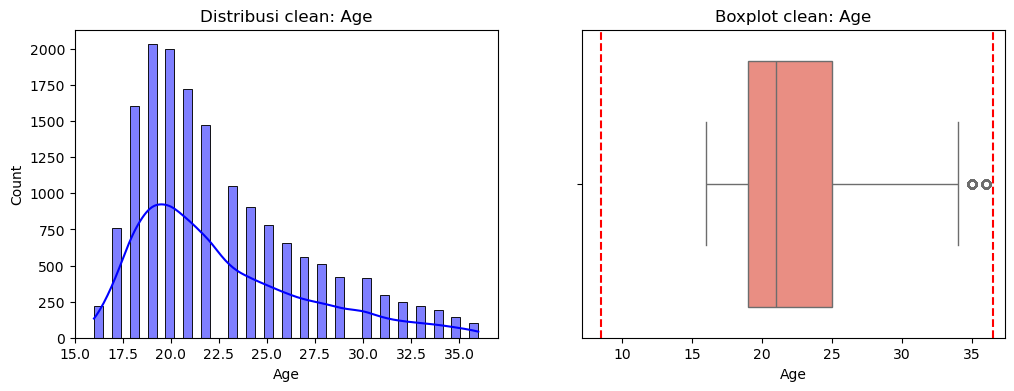

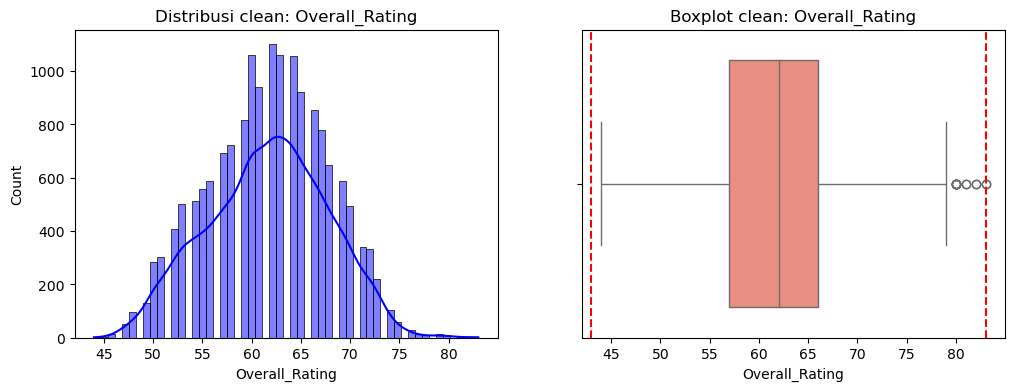

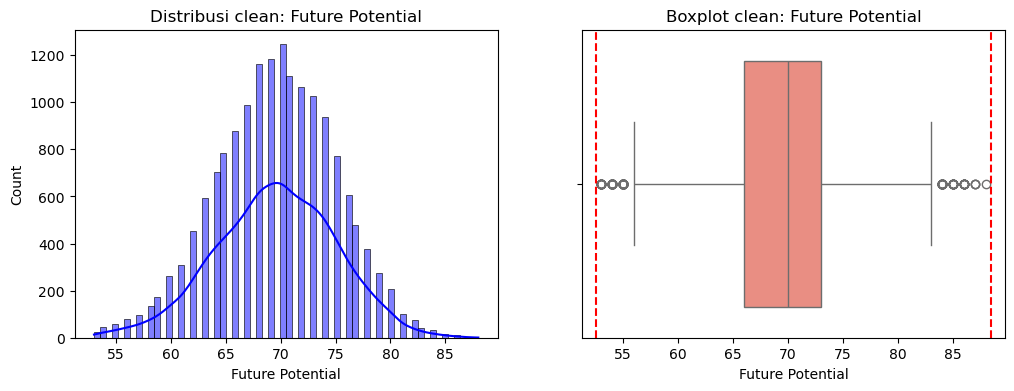

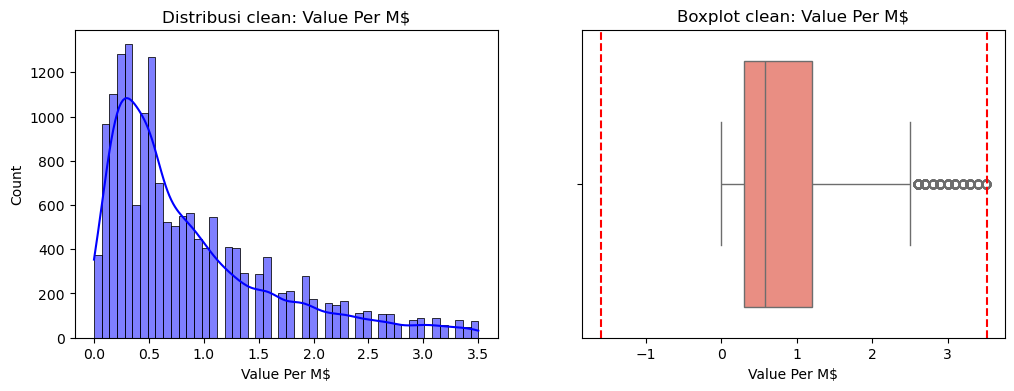

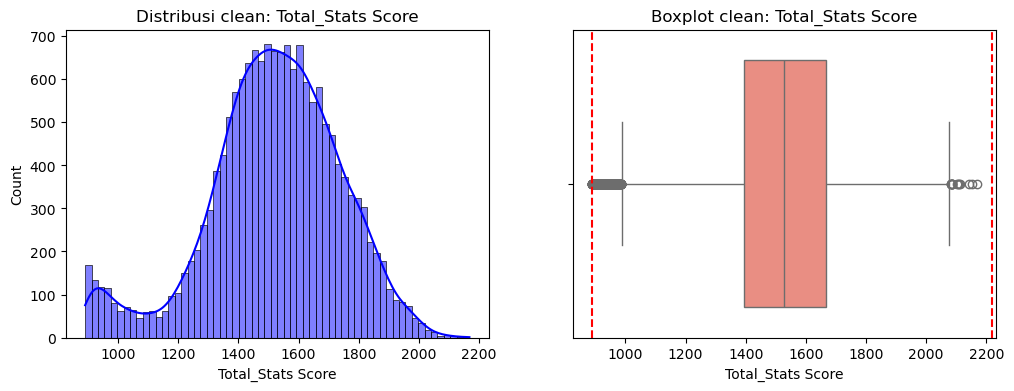

In [14]:
df_num = df.select_dtypes(include=[np.number])
for col in df_num.columns:
    plt.figure(figsize=(12, 4))
    # Boxplot Sebelum
    plt.subplot(1, 2, 1) # 1 baris, 2 kolom, posisi ke-1
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Distribusi clean: {col}')

    plt.subplot(1, 2, 2) # 1 baris, 2 kolom, posisi ke-2
    sns.boxplot(x=df[col], color='salmon')
    plt.axvline(lower_fence[col], color='red', linestyle='--', label='Lower fence asli')
    plt.axvline(higher_fence[col], color='red', linestyle='--', label='Upper fence asli')
    plt.title(f'Boxplot clean: {col}')
df.shape

In [15]:
for col in df_num.columns:
    outlier = df[
        (df[col] < lower_fence[col]) |
        (df[col] > higher_fence[col])
    ]
    print(f"{col}: {len(outlier)} outlier")

Age: 0 outlier
Overall_Rating: 0 outlier
Future Potential: 0 outlier
Value Per M$: 0 outlier
Total_Stats Score: 0 outlier


In [21]:
df.head(5)

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16313 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               16313 non-null  object 
 1   Country            16313 non-null  object 
 2   Position           16313 non-null  object 
 3   Age                16313 non-null  int64  
 4   Overall_Rating     16313 non-null  int64  
 5   Future Potential   16313 non-null  int64  
 6   Team               16313 non-null  object 
 7   Value Per M$       16313 non-null  float64
 8   Total_Stats Score  16313 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.2+ MB


In [32]:
df_str = df.select_dtypes(include=['object'])
for col in df_str.columns:
    print(f"nilai unik kolom {col}")
    print(df_str[col].unique())
    print("-"*50)

nilai unik kolom Name
['Agostinho Mabululu' 'Mahmoud Gennesh' 'Sobhi Suleiman' ...
 'Hayato Fukushima' 'Ömer Tokaç' 'Ko Sawada']
--------------------------------------------------
nilai unik kolom Country
['Angola' 'Egypt' 'Nigeria' 'Mexico' 'England' 'Paraguay' 'Uruguay'
 'Republic of Ireland' 'Belgium' 'Italy' 'Spain' 'Portugal'
 "Côte d'Ivoire" 'Argentina' 'Norway' 'United States' 'Netherlands'
 'Germany' 'Ghana' 'Serbia' 'France' 'Senegal' 'Qatar' 'Sweden' 'Colombia'
 'Ecuador' 'Australia' 'Puerto Rico' 'Luxembourg' 'Switzerland' 'Poland'
 'Scotland' 'Brazil' 'Czech Republic' 'Morocco' 'Northern Ireland'
 'Romania' 'Jamaica' 'Turkey' 'Iceland' 'Wales' 'Ukraine' 'New Zealand'
 'Greece' 'China PR' 'Kosovo' 'Iraq' 'Denmark' 'Burkina Faso' 'Austria'
 'Venezuela' 'Mali' 'Congo DR' 'Guinea' 'Algeria' 'Canada' 'Croatia'
 'Korea Republic' 'Georgia' 'Gambia' 'Chile' 'Hungary' 'Israel' 'Tunisia'
 'Jordan' 'Zimbabwe' 'Cyprus' 'Japan' 'Panama' 'Curacao' 'Kenya' 'Haiti'
 'Slovenia' 'Sierra Leon

In [33]:
df_ordinal = df[['Position','Team','Country']]
df_ordinal.head(5)

,Position,Team,Country
0,LW,Ittihad Alexandria,Angola
1,GK,Ittihad Alexandria,Egypt
2,GK,Ittihad Alexandria,Egypt
3,CB,Ittihad Alexandria,Egypt
4,CB,Ittihad Alexandria,Egypt


In [34]:
encoder = OrdinalEncoder()
encoded = encoder.fit_transform(df[df_ordinal.columns])
df[df_ordinal.columns] = encoded


In [36]:
df.head(5)

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,4.0,8.0,30,68,68,461.0,0.65,1660
1,Mahmoud Gennesh,44.0,5.0,35,67,67,461.0,0.35,1620
2,Sobhi Suleiman,44.0,5.0,28,63,65,461.0,0.20,1480
3,Mahmoud Alaa,44.0,1.0,32,68,68,461.0,0.50,1695
4,Mahmoud Shabana,44.0,1.0,30,66,66,461.0,0.40,1640


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16313 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               16313 non-null  object 
 1   Country            16313 non-null  float64
 2   Position           16313 non-null  float64
 3   Age                16313 non-null  int64  
 4   Overall_Rating     16313 non-null  int64  
 5   Future Potential   16313 non-null  int64  
 6   Team               16313 non-null  float64
 7   Value Per M$       16313 non-null  float64
 8   Total_Stats Score  16313 non-null  int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 1.2+ MB


In [40]:
df_normal = df.select_dtypes(include=['int64'])
df_normal.head(5)


,Age,Overall_Rating,Future Potential,Total_Stats Score
0,30,68,68,1660
1,35,67,67,1620
2,28,63,65,1480
3,32,68,68,1695
4,30,66,66,1640


In [ ]:
scaler = MinMaxScaler()
normal = scaler.fit_transform(df[df_normal.columns])
df[df_normal.columns] = normal
df.head(5)

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,4.0,8.0,0.70,0.615385,0.428571,461.0,0.65,0.602504
1,Mahmoud Gennesh,44.0,5.0,0.95,0.589744,0.400000,461.0,0.35,0.571205
2,Sobhi Suleiman,44.0,5.0,0.60,0.487179,0.342857,461.0,0.20,0.461659
3,Mahmoud Alaa,44.0,1.0,0.80,0.615385,0.428571,461.0,0.50,0.629890
4,Mahmoud Shabana,44.0,1.0,0.70,0.564103,0.371429,461.0,0.40,0.586854


In [43]:
df.to_csv('data bersih/fifa_player_skor_claning.csv',index=False)